# Week 4 - Univariate Analysis, part 2
Keshia-Lee Martin<br>
OMDS-ModB2<br>
Media and Entertainment<br>

Datasets: <br>
[4 Services Streaming Movies and Tv](https://www.kaggle.com/datasets/sc0v1n0/4-services-streaming-movies-and-tv/data)<br>
[Movie Box Office Dataset (2000-2024)](https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024)

# Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

### Response 
Both graphs are adaquate and tell a story. The following are the pros and cons:

<b>Histogram - Pros:</b>
1. This shows the full distribution shape of the data, which is right skewed.
2. It is showing the frequency of the drugs at each cost point, directly showing their price bracket.
3. Visibilty shows how much of the drugs are on the "cheaper" end compared to the others.

<b>Histogram - Cons:</b>
1. This is less percise for what we're looking for, which is how much more the expensive drugs tend to cost. 

<b>Box Plot - Pros</b>
1. This is more precise and shows the quantiles, median and the outliers.
2. This is answering the question of the expensive drugs, which are the outliers, highlighting them extremely well.

<b>Box Plot - Cons</b>
1. The box plot doesn't show the distribution. We cannot see the shapes or any patterns.
2. There is no way of known what the sample size is of the data. Even outliers may overlap.

In conclusion, the Box Plot is the best option for this question. We can clearly see how much the more expensive drugs tend to cost, compared to the others which are within the range and quantile of the mean.

To improve the box plot, I would expand the y axis in order to show less overlap of the prices. I would also add a title, label the y axis, and change the name of the x axis. I would also possibly add some more color to the outliers, just to show how many they are and to make the graph more engaging.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

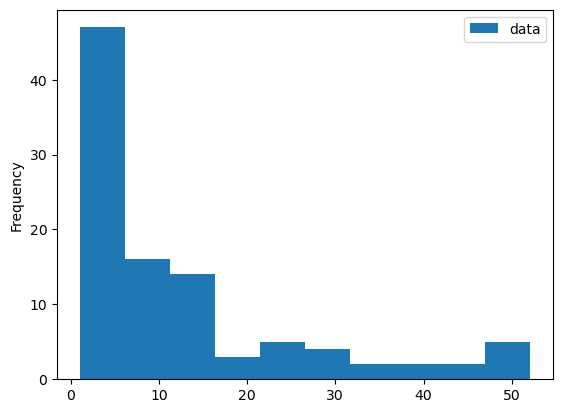

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

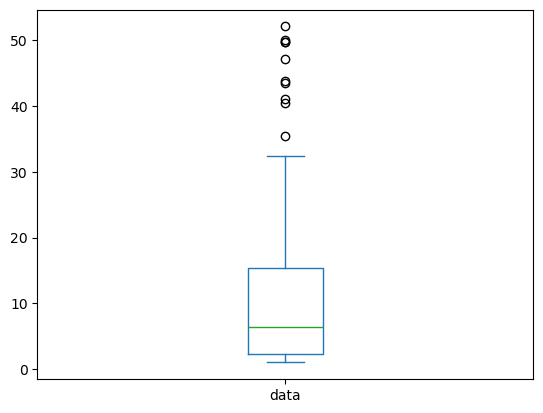

In [4]:
df.plot.box()

# Univariate Analysis of Movie Datasets

In [5]:
df_box_office = pd.read_csv('movie_box_office_cv2.csv')
df_stream = pd.read_csv('movie_tv_stream_cv3.csv')

## Streaming Movies and TV Dataset

### Histograms

Below we will begin to make histograms of all of the necessarily numerical columns. This will show us the distribution of the data, the count in range, and show us any necessary patterns that will enhance our analysis.

As a quick update, the year added date and year added year will be changed to integers from floats. This will be modified in an updated fix in the csv.

In [6]:
# CHANGING TYPE FROM FLOAT TO INTEGER
df_stream['year_added_platform'] = df_stream['year_added_platform'].astype('Int64')
df_stream['day_added_platform'] = df_stream['day_added_platform'].astype('Int64')
df_stream = df_stream.rename(columns={'Unnamed: 0': 'no_genre'})
df_stream = df_stream.rename(columns={'gender_type': 'genre_type'})


In [7]:
df_stream.to_csv('movie_tv_stream_cv3.csv', index=False)

In [8]:
# PRINTING THE LIST OF COLUMNS
print('--------------------------')
print('List of Columns (120 columns)')
print('--------------------------\n')
print(df_stream.columns.tolist())

--------------------------
List of Columns (120 columns)
--------------------------

['movie_or_tv_show', 'title', 'director', 'cast', 'country', 'date_added_platform', 'release_year', 'duration_seconds', 'genre_type', 'description', 'channel_streaming', 'no_genre', 'action', 'actionadventure', 'adult', 'adventure', 'animals', 'animation', 'anime', 'anthology', 'arthouse', 'arts', 'biographical', 'black', 'british', 'buddy', 'cartoons', 'children', 'classic', 'comedy', 'coming', 'concert', 'cooking', 'crime', 'cult', 'dance', 'documentary', 'docuseries', 'drama', 'faith', 'family', 'fantasy', 'fitness', 'game', 'health', 'historical', 'history', 'horror', 'independent', 'international', 'latino', 'lgbtq', 'lifestyle', 'military', 'music', 'musical', 'mystery', 'news', 'reality', 'romance', 'scifi', 'series', 'spanishlanguage', 'special', 'sports', 'suspense', 'talk', 'thriller', 'unscripted', 'variety', 'western', 'young', 'competition', 'culture', 'disaster', 'entertainment', 'feature

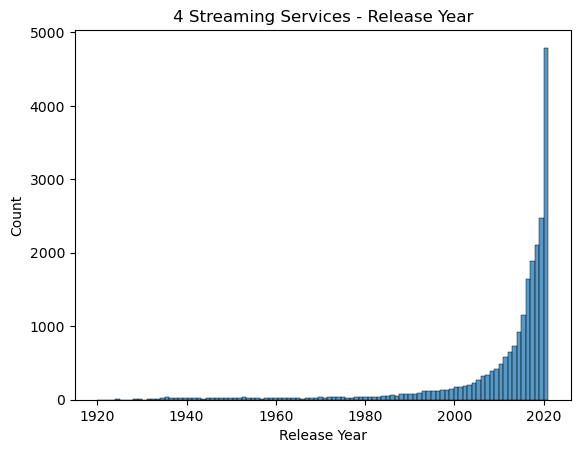

---------------------
MINIMUM RELEASE YEAR: 1920
MAX RELEASE YEAR: 2021
MEAN: 2010.8112444560397
MEDIAN: 2016.0
MODE: 2019
---------------------


In [9]:
# RELEASE HISTOGRAMS
sns.histplot(df_stream["release_year"], bins=100)
plt.title('4 Streaming Services - Release Year')
plt.xlabel('Release Year')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RELEASE YEAR: {np.min(df_stream["release_year"])}')
print(f'MAX RELEASE YEAR: {np.max(df_stream["release_year"])}')
print(f'MEAN: {np.mean(df_stream["release_year"])}')
print(f'MEDIAN: {np.median(df_stream["release_year"])}')
print(f'MODE: {(df_stream["release_year"]).mode()[0]}')
print('---------------------')

First, we have the <b>Release Year</b> left skewed histogram. Most of the movies on the streaming platforms had a release date in the 2000s. In fact, the most were in the year 2020 and beyond. Streaming services became incredibly popular as the years have went by. With more competition, more streaming services have entered the consumer race, adding more and more of the latest movies and tv shows to their catalog. The newer the movie is and if the release date is closest to the current day, streaming services will push to have them on their platform. This increases viewership, as many people wait for movies that are in the theatres to be released on a streaming service.

There are multiple outliers as early as 1940. The minimum release year is 1920, with the maximum release year being in 2021. The mean is ~2010.8, the median is 2020, and the mode is 2019. 

The bin number does not affect the histogram until past 100. Then, the release date holes show for the programs that are on the streaming services.

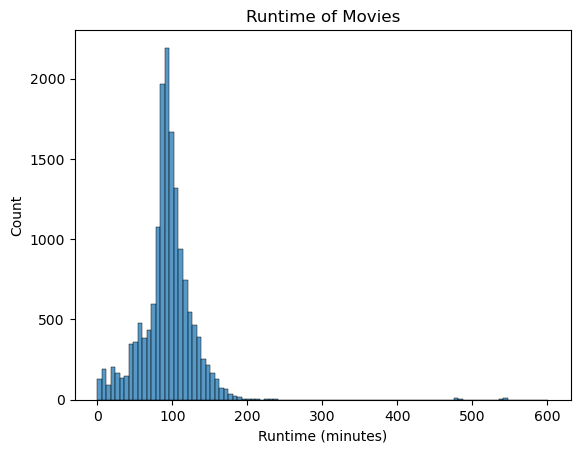

---------------------
MINIMUM RUNTIME: 0.0
MAX RUNTIME: 601.0
MEAN: 93.63885242827676
MEDIAN: nan
MODE: 90.0
---------------------


In [10]:
# RUNTIME OF MOVIES HISTOGRAM
sns.histplot(df_stream["runtime_minutes"], bins=100)
plt.title('Runtime of Movies')
plt.xlabel('Runtime (minutes)')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["runtime_minutes"])}')
print(f'MAX RUNTIME: {np.max(df_stream["runtime_minutes"])}')
print(f'MEAN: {np.mean(df_stream["runtime_minutes"])}')
print(f'MEDIAN: {np.median(df_stream["runtime_minutes"])}')
print(f'MODE: {(df_stream["runtime_minutes"]).mode()[0]}')
print('---------------------')

The <b>Runtime of Movies</b> histogram shows us the length of movies in minutes. This has a nice bell curve that is right skewed. Most movies are in the 100 minute range, ~ an hour and half. This "sweet spot" comes from a person's attention span. As the length runtime in minutes continues in the histogram, the number of movies in those ranges go down. This makes sense for streaming services to have movies in this range as they can lead to another movie or tv show being watched.

There are outliers that are past 450 in runtime, which with further analysis can review the movie and genre details of the entry.

There is a minimum runtime of 0 (run time was not reported and simply reported as 0 versus leaving blank), a max runtime of 601 minutes, a mean runtime of 93.64, a median of nan (data missing), and a mode of 90 minutes.

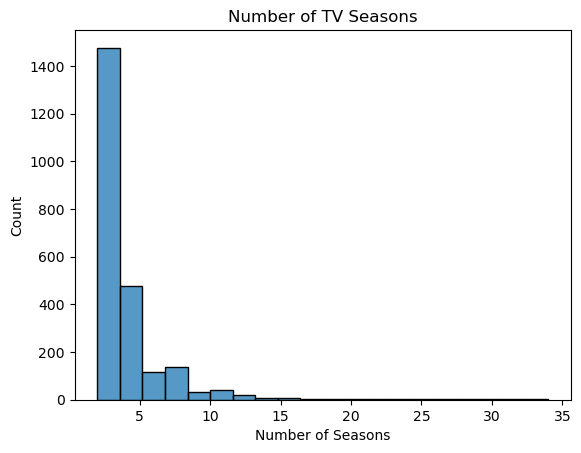

---------------------
MINIMUM RUNTIME: 2.0
MAX RUNTIME: 34.0
MEAN: 3.8136246786632393
MEDIAN: nan
MODE: 2.0
---------------------


In [43]:
sns.histplot(df_stream["tv_season"], bins=20)
plt.title('Number of TV Seasons')
plt.xlabel('Number of Seasons')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["tv_season"])}')
print(f'MAX RUNTIME: {np.max(df_stream["tv_season"])}')
print(f'MEAN: {np.mean(df_stream["tv_season"])}')
print(f'MEDIAN: {np.median(df_stream["tv_season"])}')
print(f'MODE: {(df_stream["tv_season"]).mode()[0]}')
print('---------------------')

The <b>Number of Seasons</b> histogram is right skewed, show that most tv shows on the streaming services only have 1-5 seasons. This is the typical range on many tv shows on streaming services. Now, nearly every streaming service has their own tv shows and miniseries. With miniseries being only one season, multiple shows being cut after the first season due to lower viewership or budget, and show quality decreasing after multiple seasons, streaming services do not host many shows with more than 5 seasons. Next, it would be very interesting to see the years of release against the tv seasons.

### Histogram Variants

<b>Swarm Plots</b> can be used when there is a categorical variable, a numeric variable, and when one wants to see every single point without any overlap. With the amount of points in the data set, the swarm plot is overcrowded and cannot be used for this specific dataset without getting a smaller sample of data.


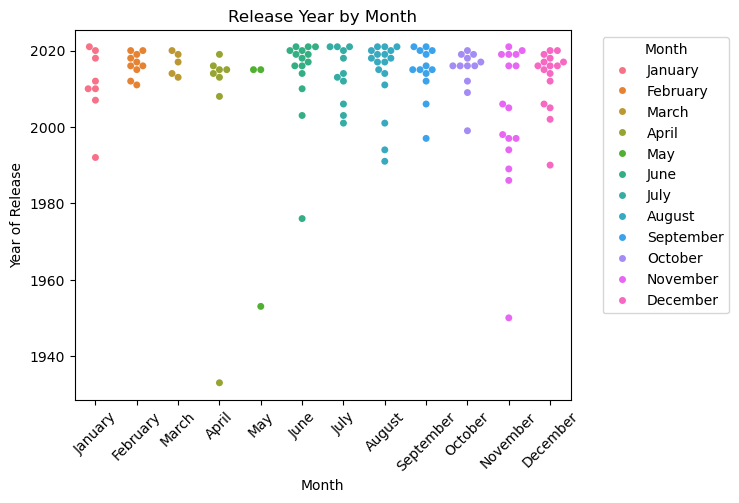

In [36]:
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
df_stream['month_name'] = pd.Categorical(df_stream['month_name'], categories=month_order, ordered=True)

df_stream_sample = df_stream.sample(250)
sns.swarmplot(data=df_stream_sample, x="month_name", y="release_year", hue='month_name')
plt.title("Release Year by Month")
plt.xlabel('Month')
plt.xticks(rotation= 45)
plt.ylabel('Year of Release')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1))
plt.show()

The <b>Violin Plot</b> shows a very similar analysis, but by streaming platform. The Disnet and Amazon platforms have thicker lines compared to Netflix and Hulu for the tv shows and movies they have that have older release dates. Disney especially has some more between roughly 1960 and 1930, when many of their classics such as Sleeping Beauty and Snow White were released. Netflix has a wider range of movies that are in the late 2000's compared to the other platforms. Disney's becomes quite thin, with less tv show and movies that were released in the late 2000's. This is likely due to more original series, miniseries, and movies that are added to Netflix, Hulu, and Amazon Prime's platforms.

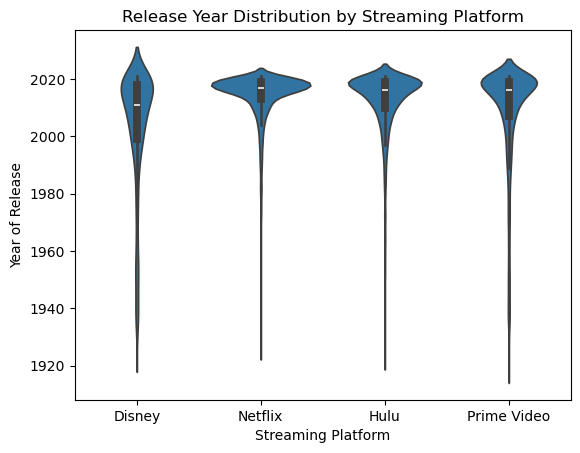

In [37]:
sns.violinplot(data=df_stream, x='channel_streaming', y='release_year')
plt.title('Release Year Distribution by Streaming Platform')
plt.xlabel('Streaming Platform')
# plt.xticks(rotation= 45)
plt.ylabel('Year of Release')
plt.show()

For the <b>Violin Plot </b> for Movie and TV Show, an extremely large amount of tv shows were added to the streaming services in the 2020s compared to movies.

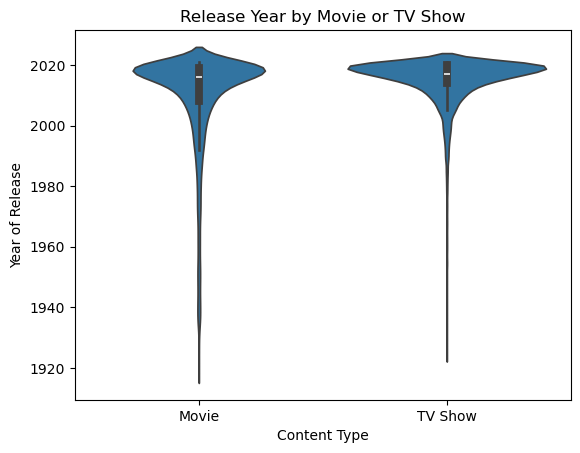

In [14]:
sns.violinplot(data=df_stream, x="movie_or_tv_show", y="release_year")
plt.title("Release Year by Movie or TV Show")
plt.xlabel('Content Type')
plt.ylabel('Year of Release')
plt.show()

### Bar Graphs

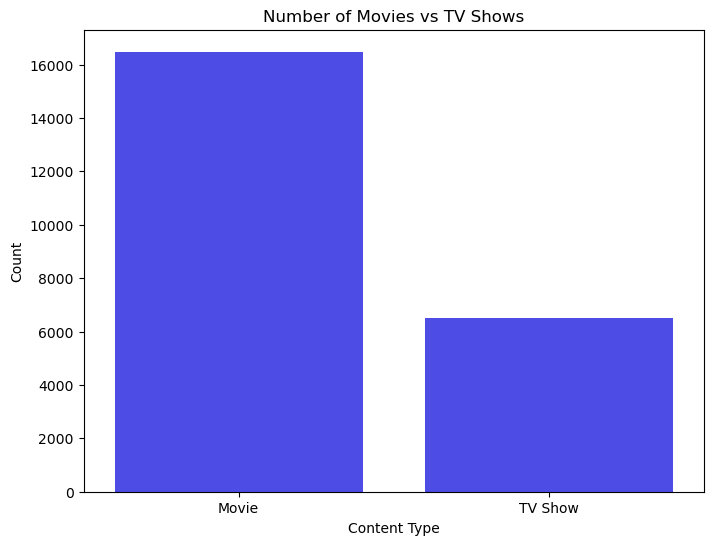

-------------- CONTENT TYPE COUNTS --------------
Movie: 16481
TV Show: 6517


In [41]:
# BAR GRAPH FOR MOVIE AND TV SHOW

plt.figure(figsize=(8, 6))
sns.countplot(x=df_stream['movie_or_tv_show'], color='blue', alpha=0.8)
plt.title('Number of Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

content_counts = df_stream['movie_or_tv_show'].value_counts()

print('-------------- CONTENT TYPE COUNTS --------------')
for content_type, count in content_counts.items():
    print(f'{content_type}: {count}')

For the <b>Bar Graphs</b>, both genres and countries are binary. So, lists had to be created to ensure the correct data was appearing as intended. Based on the bar graph for genres, the top 5 genres are Drama, International Content, Comedy, Action, and Adventure, with Horror following behind.

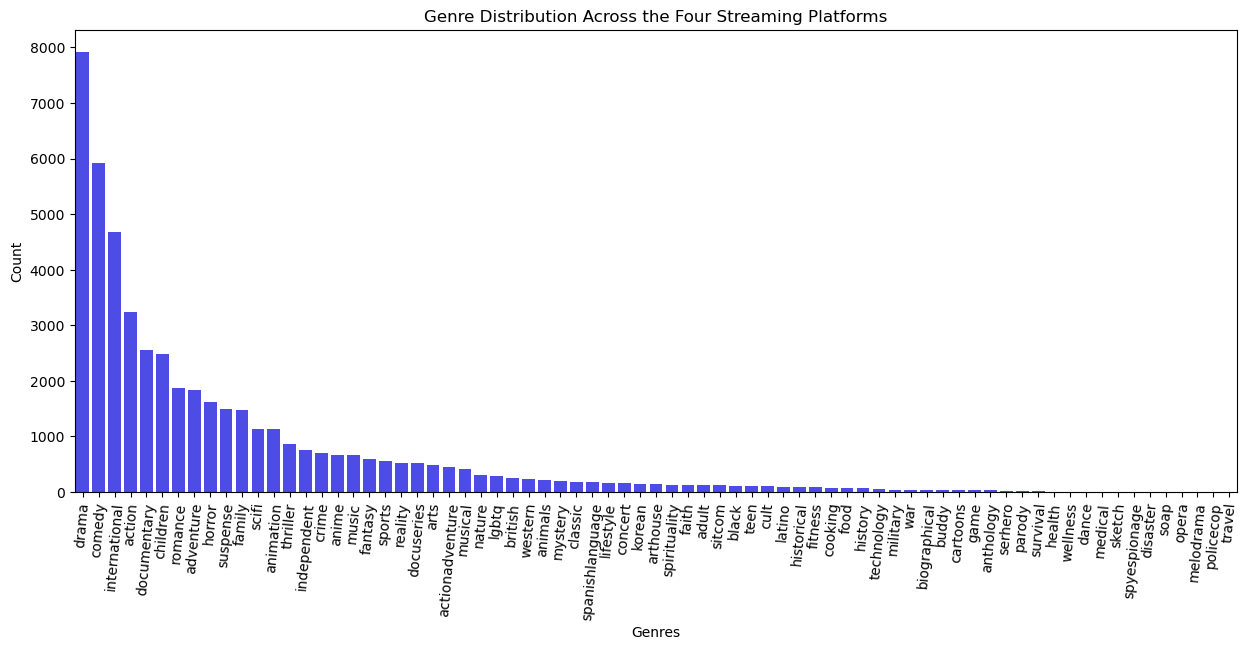

-------------- GENRE COUNTS --------------

There are 73 unique genres
The top 10 genres on the 4 streaming services are:
drama            7918
comedy           5912
international    4674
action           3239
documentary      2560
children         2480
romance          1867
adventure        1842
horror           1611
suspense         1501
dtype: int64


In [45]:
# BAR GRAPH FOR GENRES
genre_cols = ['action', 'actionadventure', 'adventure', 'adult', 'animals', 'animation', 'anime', 'anthology', 'arthouse', 'arts', 'biographical', 'black', 'british', 'buddy', 'cartoons', 'children', 'classic', 'comedy', 'concert', 'cooking', 'crime', 'cult', 'dance', 'documentary', 'docuseries', 'drama', 'faith', 'family', 'fantasy', 'fitness', 'game', 'health', 'historical', 'history', 'horror', 'independent', 'international', 'latino', 'lgbtq', 'lifestyle', 'military', 'music', 'musical', 'mystery', 'reality', 'romance', 'scifi', 'spanishlanguage', 'sports', 'suspense', 'thriller', 'western', 'disaster', 'food', 'korean', 'nature', 'parody', 'serhero', 'sitcom', 'spirituality', 'technology', 'teen', 'war', 'wellness', 'medical', 'policecop', 'sketch', 'soap', 'spyespionage', 'survival', 'opera', 'travel', 'melodrama']

# SUM EACH GENRE AND THEN SORT VALUES
genre_count = df_stream[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=genre_count.index, y = genre_count.values, color = 'blue', alpha=.8)
plt.title('Genre Distribution Across the Four Streaming Platforms')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=85)
plt.show()

top_10_genres = genre_count.head(10)

print("-------------- GENRE COUNTS --------------")
print(f"\nThere are {len(genre_count)} unique genres")
print("The top 10 genres on the 4 streaming services are:")
print(top_10_genres)


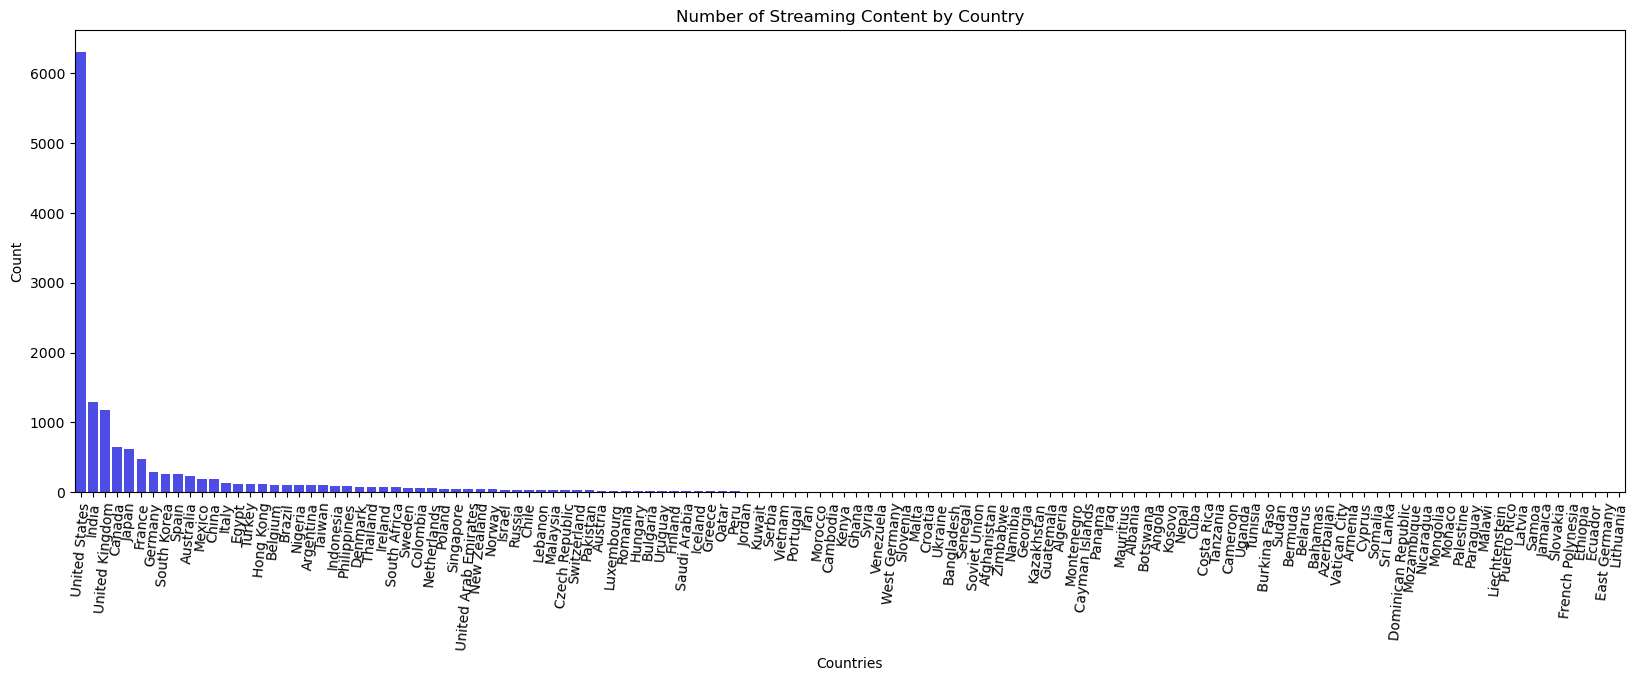

-------------- COUNTRY COUNTS --------------

There are 128 countries.
The top 10 countries on the 4 streaming services are:
United States     6305
India             1299
United Kingdom    1174
Canada             645
Japan              615
France             475
Germany            293
South Korea        260
Spain              258
Australia          225
dtype: int64

-------------- COUNTRY COUNTS --------------

The countries that only have one movie or tv show on the streaming services are:
Cuba                  1
Costa Rica            1
Tanzania              1
Cameroon              1
Uganda                1
Tunisia               1
Burkina Faso          1
Sudan                 1
Bermuda               1
Belarus               1
Bahamas               1
Azerbaijan            1
Vatican City          1
Armenia               1
Cyprus                1
Somalia               1
Sri Lanka             1
Dominican Republic    1
Mozambique            1
Nicaragua             1
Mongolia              1


In [16]:
# BAR GRAPH FOR COUNTRY
country_cols = ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Belarus', 'Belgium', 'Bermuda', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt', 'Ethiopia', 'Finland', 'France', 'French Polynesia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Latvia', 'Lebanon', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Monaco', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Nigeria', 'Norway', 'Pakistan', 'Palestine', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Romania', 'Russia', 'Samoa', 'Saudi Arabia', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'Somalia', 'South Africa', 'South Korea', 'Soviet Union', 'Spain', 'Sri Lanka', 'Sudan', 'Sweden', 'Switzerland', 'Syria', 'Taiwan', 'Tanzania', 'Thailand', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uruguay', 'Vatican City', 'Venezuela', 'Vietnam', 'West Germany', 'Zimbabwe']

# SUM EACH GENRE AND THEN SORT VALUES
country_count = df_stream[country_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(20, 6))
sns.barplot(x=country_count.index, y = country_count.values, color = 'blue', alpha=.8)
plt.title('Number of Streaming Content by Country')
plt.xlabel('Countries')
plt.ylabel('Count')
plt.xticks(rotation=85)
plt.show()

top_10_countries = country_count.head(10)
lowest_countries = country_count.tail(36)

print("-------------- COUNTRY COUNTS --------------")
print(f"\nThere are {len(country_count)} countries.")
print("The top 10 countries on the 4 streaming services are:")
print(top_10_countries)

print("\n-------------- COUNTRY COUNTS --------------")
print("\nThe countries that only have one movie or tv show on the streaming services are:")
print(lowest_countries)

### Conclusions - Streaming Movie and TV ###

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If they are not useable, find some new data!

What is the overall shape of the distribution? Is it normal, skewed, bimodal, uniform, etc.?

Are there any outliers present? (Data points that are far from the others.)

If there are multiple related histograms, how does the distribution change across different groups?

What are the minimum and maximum values represented in each histogram?

How do bin sizes affect the histogram? Does changing the bin width reveal different patterns in the data?

Does the distribution appear normal, or does it have a different distribution?

### Conclusions - Streaming Movie and TV ###

**Release Year:** The distribution is left skewed, with the majority of content 
released between 2015 and 2021. This is expected as streaming platforms prioritize 
the most recent content to attract subscribers and retain them. Outliers as early as 1920 represent classic films added for catalog depth and nostaglia, particularly on Disney+.

**Runtime:** The runtime distribution is right skewed with a peak around 90 minutes, 
reflecting industry standards for feature films. Outliers above 450 minutes likely 
represent multi-part documentaries or miniseries mistakenly categorized as movies. 
A minimum of 0 minutes indicates missing runtime data rather than actual zero-length 
content.

**TV Seasons:** Right skewed, with most shows having 1-3 seasons. This reflects the 
rise of limited series and miniseries on streaming platforms, as well as early 
cancellations due to viewership metrics. The longer season shows tend to be ones that debuted on national television versus being produced by the streaming service. Those look to be the outliers in the graphs.

**Genre Distribution:** Drama, International, and Comedy dominate across all four 
platforms. This is expected given the global reach of streaming services and the 
broad appeal of these genres.

**Country Distribution:** The United States dominates production volume, followed 
by the United Kingdom and India. 36 countries had only a single title, suggesting 
limited international representation on the streaming services outside major markets.


## Movie Box Office ##

In [17]:
df_box_office = df_box_office.rename(columns={'Release Group': 'Movie Title'})

In [18]:
df_box_office.to_csv('movie_box_office_cv2.csv', index=False)

In [19]:
# PRINTING THE LIST OF COLUMNS
print('--------------------------')
print('List of Columns (108 columns)')
print('--------------------------\n')
print(list(df_box_office))

--------------------------
List of Columns (108 columns)
--------------------------

['Rank', 'Movie Title', '$Worldwide', '$Domestic', 'Domestic %', '$Foreign', 'Foreign %', 'Year', 'Genres', 'Rating', 'Vote_Count', 'Original_Language', 'Production_Countries', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'Algeria', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Belarus', 'Belgium', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Guadaloupe', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Ireland', 'Italy', 'Japan', 'Kazakhstan', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'New Ze

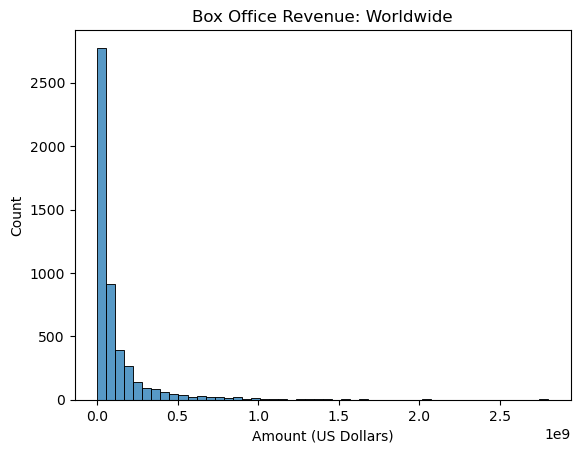

---------------------
MINIMUM YEAR TO BOX OFFICE: 1666028.0
MAX YEAR TO BOX OFFICE: 2799439100.0
MEAN: 119213693.2098
MEDIAN: 48446575.0
MODE: 32800000.0
---------------------


In [20]:
# WORLDWIDE REVENUE HISTOGRAMS
sns.histplot(df_box_office["$Worldwide"], bins=50)
plt.title('Box Office Revenue: Worldwide')
plt.xlabel('Amount (US Dollars)')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM YEAR TO BOX OFFICE: {np.min(df_box_office["$Worldwide"])}')
print(f'MAX YEAR TO BOX OFFICE: {np.max(df_box_office["$Worldwide"])}')
print(f'MEAN: {np.mean(df_box_office["$Worldwide"])}')
print(f'MEDIAN: {np.median(df_box_office["$Worldwide"])}')
print(f'MODE: {(df_box_office["$Worldwide"]).mode()[0]}')
print('---------------------')

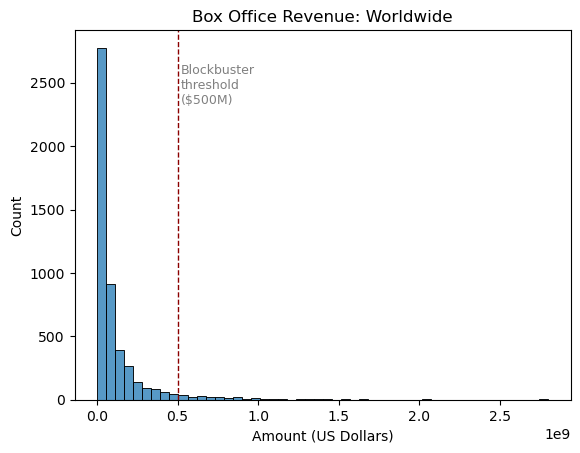

In [50]:
# WORLDWIDE REVENUE HISTOGRAM WITH BLOCKBUSTER THRESHOLD
sns.histplot(df_box_office["$Worldwide"], bins=50)

# Add a line marking the blockbuster threshold
blockbuster_line = 500_000_000  # $500M — common blockbuster benchmark
plt.axvline(x=blockbuster_line, color='darkred', linestyle='--', linewidth=1)
plt.text(blockbuster_line + 20_000_000, plt.ylim()[1]*0.8, 
         'Blockbuster\nthreshold\n($500M)', color='grey', fontsize=9)

plt.title('Box Office Revenue: Worldwide')
plt.xlabel('Amount (US Dollars)')
plt.show()

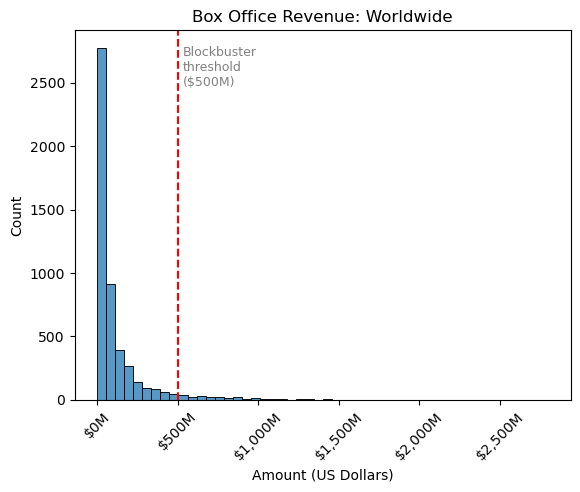

In [64]:
import matplotlib.ticker as mticker

sns.histplot(df_box_office["$Worldwide"], bins=50)

plt.axvline(x=500_000_000, color='red', linestyle='--', linewidth=1.5)
plt.text(530_000_000, plt.ylim()[1]*0.85, 'Blockbuster\nthreshold\n($500M)', 
         color='gray', fontsize=9)

plt.title('Box Office Revenue: Worldwide')
plt.xlabel('Amount (US Dollars)')

# FORMAT X AXIS WITH SHORTHAND NUMBERS

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x/1e6:,.0f}M')
)
plt.xticks(rotation=45)
plt.show()

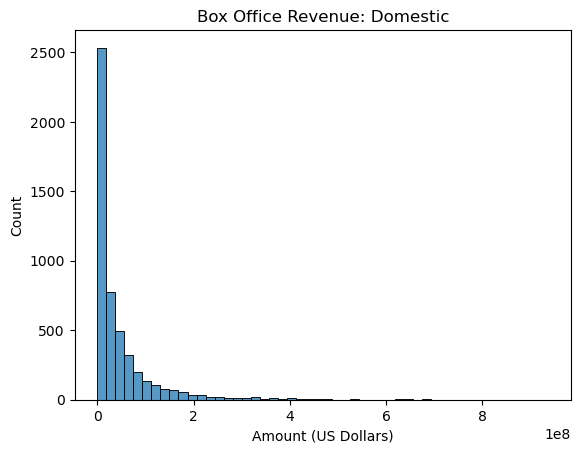

---------------------
MINIMUM YEAR TO BOX OFFICE: 0.0
MAX YEAR TO BOX OFFICE: 936662225.0
MEAN: 44725232.97
MEDIAN: 17984212.0
MODE: 0.0
---------------------


In [21]:
# DOMESTIC REVENUE HISTOGRAMS
sns.histplot(df_box_office["$Domestic"], bins=50)
plt.title('Box Office Revenue: Domestic')
plt.xlabel('Amount (US Dollars)')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM YEAR TO BOX OFFICE: {np.min(df_box_office["$Domestic"])}')
print(f'MAX YEAR TO BOX OFFICE: {np.max(df_box_office["$Domestic"])}')
print(f'MEAN: {np.mean(df_box_office["$Domestic"])}')
print(f'MEDIAN: {np.median(df_box_office["$Domestic"])}')
print(f'MODE: {(df_box_office["$Domestic"]).mode()[0]}')
print('---------------------')

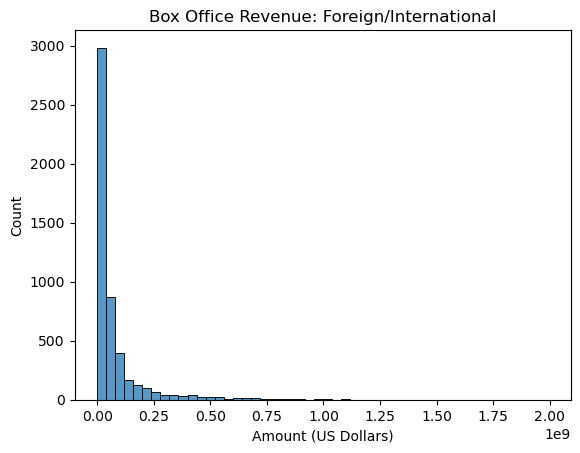

---------------------
MINIMUM YEAR TO BOX OFFICE: 0.0
MAX YEAR TO BOX OFFICE: 1993811448.0
MEAN: 74488092.7352
MEDIAN: 30194438.0
MODE: 0.0
---------------------


In [22]:
# RELEASE HISTOGRAMS
sns.histplot(df_box_office["$Foreign"], bins=50)
plt.title('Box Office Revenue: Foreign/International')
plt.xlabel('Amount (US Dollars)')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM YEAR TO BOX OFFICE: {np.min(df_box_office["$Foreign"])}')
print(f'MAX YEAR TO BOX OFFICE: {np.max(df_box_office["$Foreign"])}')
print(f'MEAN: {np.mean(df_box_office["$Foreign"])}')
print(f'MEDIAN: {np.median(df_box_office["$Foreign"])}')
print(f'MODE: {(df_box_office["$Foreign"]).mode()[0]}')
print('---------------------')

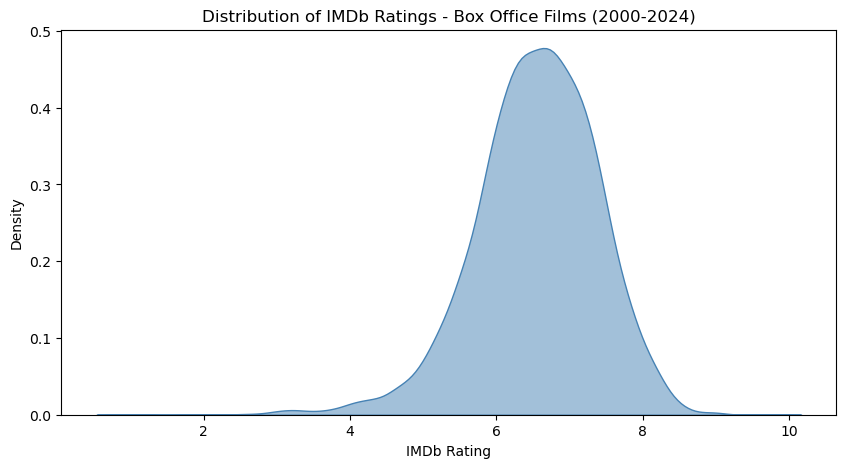

---------------------
MINIMUM RATING: 0.0
MAX RATING: 9.7
MEAN: 6.51
MEDIAN: 6.6
MODE: 6.5
---------------------


In [68]:
plt.figure(figsize=(10, 5))

# FILTER OUT THE ZERO RATINGS
rating_data = df_box_office[df_box_office['Rating'] > 0]['Rating']

sns.kdeplot(rating_data, fill=True, color='steelblue', alpha=0.5)

plt.title('Distribution of IMDb Ratings - Box Office Films (2000-2024)')
plt.xlabel('IMDb Rating')
plt.ylabel('Density')
plt.show()

print('---------------------')
print(f'MINIMUM RATING: {df_box_office["Rating"].min()}')
print(f'MAX RATING: {df_box_office["Rating"].max()}')
print(f'MEAN: {df_box_office["Rating"].mean():.2f}')
print(f'MEDIAN: {df_box_office["Rating"].median()}')
print(f'MODE: {df_box_office["Rating"].mode()[0]}')
print('---------------------')

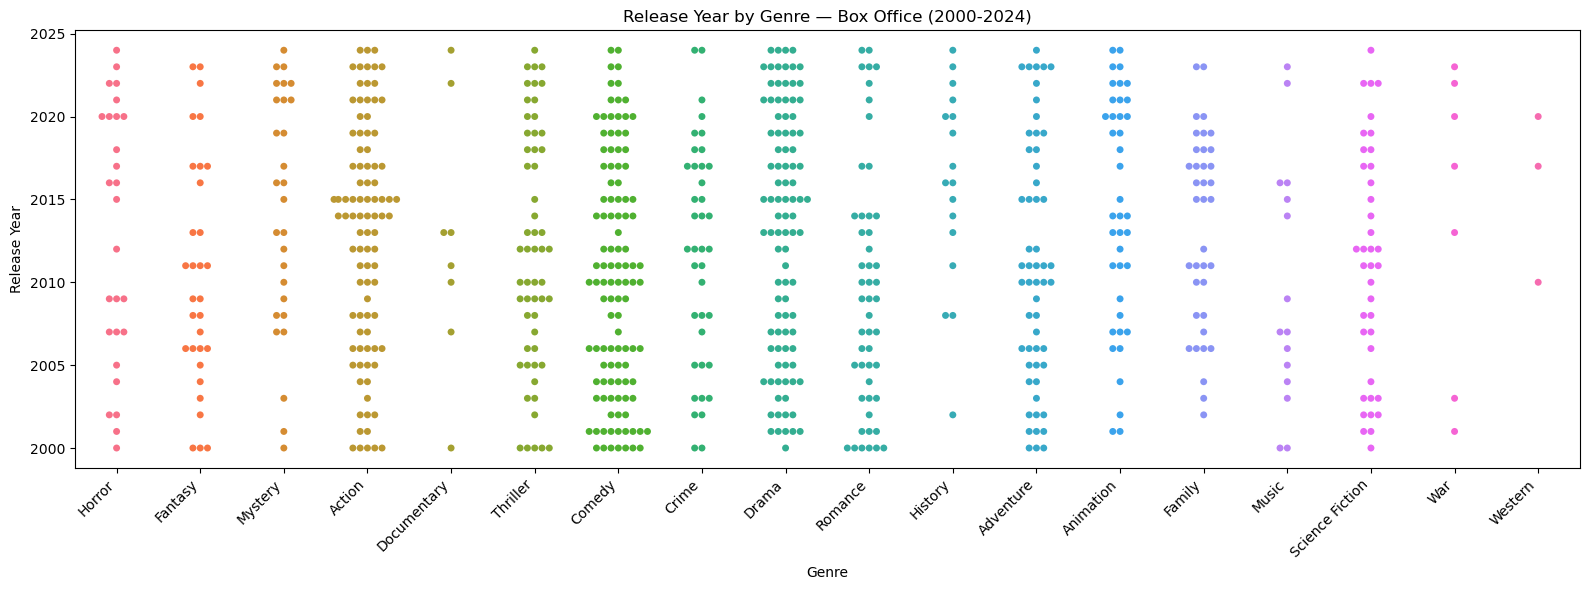

In [24]:
genre_cols_bo = [
    'Action',
    'Adventure', 
    'Animation',
    'Comedy',
    'Crime',
    'Documentary',
    'Drama',
    'Family',
    'Fantasy',
    'History',
    'Horror',
    'Music',
    'Mystery',
    'Romance',
    'Science Fiction',
    'TV Movie',
    'Thriller',
    'War',
    'Western'
]

# MELT GENRES DUE TO MOVIES BEING IN MULTIPLE GENRES
df_genre_melt = df_box_office.melt(
    id_vars=['$Worldwide', 'Year', 'Rating'],
    value_vars=genre_cols_bo,
    var_name='Genre',
    value_name='Is_Genre'
)
df_genre_melt = df_genre_melt[df_genre_melt['Is_Genre'] == 1]

# SAMPLE DOWN
df_genre_sample = df_genre_melt.sample(750)

plt.figure(figsize=(16, 6))
sns.swarmplot(data=df_genre_sample, x='Genre', y='Year', hue='Genre', legend=False)
plt.title('Release Year by Genre — Box Office (2000-2024)')
plt.xlabel('Genre')
plt.ylabel('Release Year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

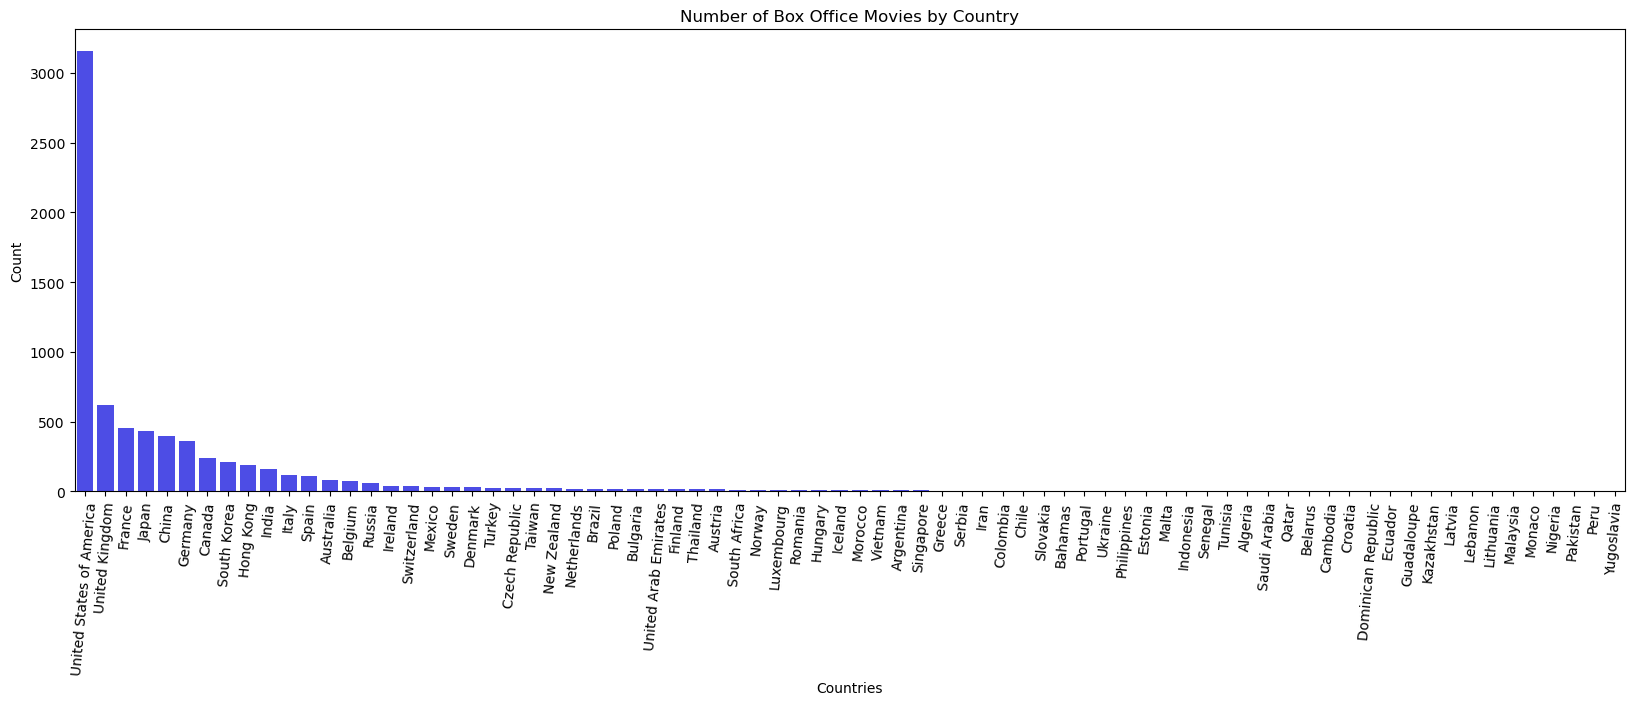

-------------- COUNTRY COUNTS --------------

There are 76 countries.


In [25]:
country_cols_bo = [
    'Algeria',
    'Argentina',
    'Australia',
    'Austria',
    'Bahamas',
    'Belarus',
    'Belgium',
    'Brazil',
    'Bulgaria',
    'Cambodia',
    'Canada',
    'Chile',
    'China',
    'Colombia',
    'Croatia',
    'Czech Republic',
    'Denmark',
    'Dominican Republic',
    'Ecuador',
    'Estonia',
    'Finland',
    'France',
    'Germany',
    'Greece',
    'Guadaloupe',
    'Hong Kong',
    'Hungary',
    'Iceland',
    'India',
    'Indonesia',
    'Iran',
    'Ireland',
    'Italy',
    'Japan',
    'Kazakhstan',
    'Latvia',
    'Lebanon',
    'Lithuania',
    'Luxembourg',
    'Malaysia',
    'Malta',
    'Mexico',
    'Monaco',
    'Morocco',
    'Netherlands',
    'New Zealand',
    'Nigeria',
    'Norway',
    'Pakistan',
    'Peru',
    'Philippines',
    'Poland',
    'Portugal',
    'Qatar',
    'Romania',
    'Russia',
    'Saudi Arabia',
    'Senegal',
    'Serbia',
    'Singapore',
    'Slovakia',
    'South Africa',
    'South Korea',
    'Spain',
    'Sweden',
    'Switzerland',
    'Taiwan',
    'Thailand',
    'Tunisia',
    'Turkey',
    'Ukraine',
    'United Arab Emirates',
    'United Kingdom',
    'United States of America',
    'Vietnam',
    'Yugoslavia'
]

# SUM EACH GENRE AND THEN SORT VALUES
country_count_bo = df_box_office[country_cols_bo].sum().sort_values(ascending=False)

plt.figure(figsize=(20, 6))
sns.barplot(x=country_count_bo.index, y = country_count_bo.values, color = 'blue', alpha=.8)
plt.title('Number of Box Office Movies by Country')
plt.xlabel('Countries')
plt.ylabel('Count')
plt.xticks(rotation=85)
plt.show()

top_10_countries = country_count.head(10)
lowest_countries = country_count.tail(36)

print("-------------- COUNTRY COUNTS --------------")
print(f"\nThere are {len(country_count_bo)} countries.")


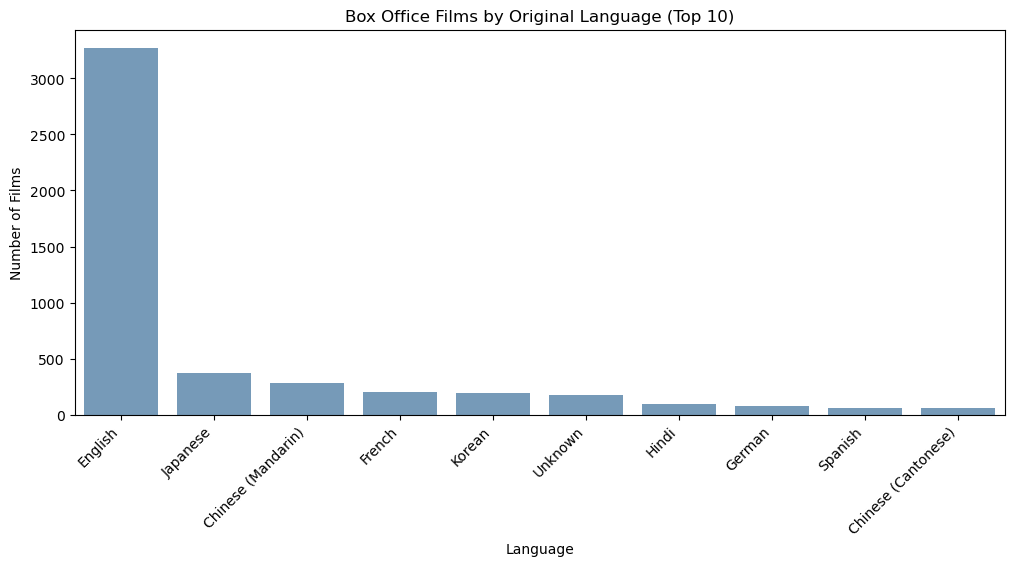

In [ ]:
# ORIGINAL LANGUAGE BAR GRAPH
lang_counts = df_box_office['Original_Language'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=lang_counts.index, y=lang_counts.values, color='steelblue', alpha=0.8)
plt.title('Box Office Films by Original Language (Top 10)')
plt.xlabel('Language')
plt.ylabel('Number of Films')
plt.xticks(rotation=45, ha='right')
plt.show()

### Conclusions - Movie Box Office ###

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If they are not useable, find some new data!

What is the overall shape of the distribution? Is it normal, skewed, bimodal, uniform, etc.?

Are there any outliers present? (Data points that are far from the others.)

If there are multiple related histograms, how does the distribution change across different groups?

What are the minimum and maximum values represented in each histogram?

How do bin sizes affect the histogram? Does changing the bin width reveal different patterns in the data?

Does the distribution appear normal, or does it have a different distribution?

### Conclusions - Movie Box Office ###

**Release Year:** The distribution is relatively uniform across 2000-2019, with a 
notable dip in 2020 reflecting the COVID-19 pandemic's impact on theatrical releases. 
Recovery is visible in 2021-2024 as theaters reopened and studios resumed wide releases.

**Worldwide Revenue:** The distribution is heavily right skewed, with the vast 
majority of films earning under $200 million worldwide. A small number of 
blockbusters in  Action, Adventure, and Animation titles, account for 
extreme outliers above $1 billion. This is expected in the film industry where 
a small number of releases generate disproportionate revenue.

**Domestic vs. Foreign Split:** Many films show a higher foreign revenue percentage, 
reflecting the growing importance of international markets, particularly China, 
for Hollywood productions.

**Genre Distribution:** Action and Adventure dominate box office revenue, while 
Drama, despite being the most common genre on streaming platforms, shows 
significantly lower average theatrical revenue. This suggests a meaningful 
difference between what performs theatrically versus what audiences consume 
on streaming.

**Outliers:** Outside of the Year, there are outliers in every numerical column. The higher ranked movies have higher revenues. There are also many movies that dont have their worldwide and domestic revenue reported, so this greatly skews the data.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

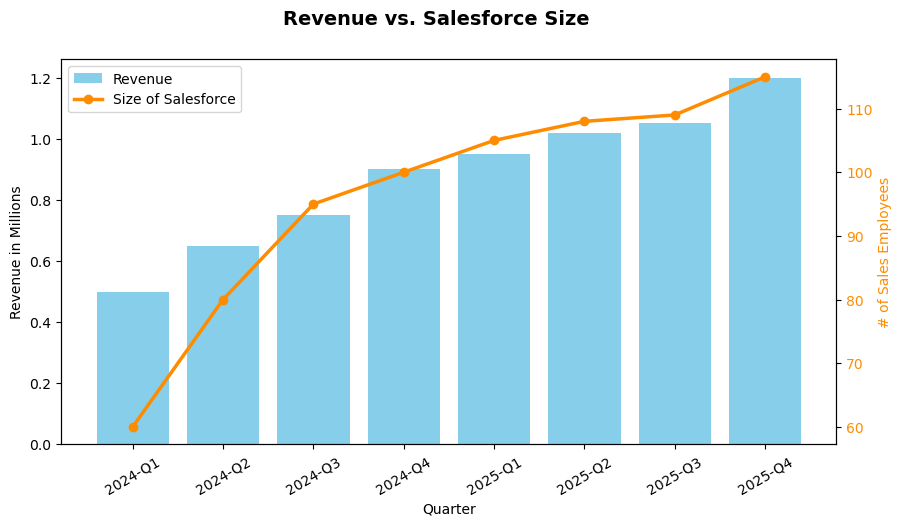

In [26]:
# data
year_quarters = ["2024-Q1", "2024-Q2", "2024-Q3", "2024-Q4",
                 "2025-Q1", "2025-Q2", "2025-Q3", "2025-Q4"
                 ]
revenue = [0.5, 0.65, 0.75, 0.9, 0.95, 1.02, 1.05, 1.20]
salesforce_size = [60, 80, 95, 100, 105, 108, 109, 115]

x = np.arange(len(year_quarters))
fig, ax1 = plt.subplots(figsize=(10, 5))

# bar chart for the revenue
bar_width = 0.8
bars = ax1.bar(x, revenue, width=bar_width, color= "skyblue", label="Revenue")

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Revenue in Millions", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticks(x)
ax1.set_xticklabels(year_quarters, rotation=30)

# creating second axis
ax2 = ax1.twinx()
line = ax2.plot(x, salesforce_size, color="darkorange", marker="o", linewidth=2.5, label="Size of Salesforce")
ax2.set_ylabel("# of Sales Employees", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# title and legend for the graphs
fig.suptitle("Revenue vs. Salesforce Size", fontsize=14, fontweight="bold")
lines_labels = [bars, line[0]]
labels = [l.get_label() for l in lines_labels]
ax1.legend(lines_labels, labels, loc="upper left")
plt.show()